In [56]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
import h5py
import h5_utilities_module as h5u
from pathlib import Path

In [59]:
def calculate_mean_and_interval(data, type='sem', num_samples=1000, alpha=0.05):
    input_1d = data.ndim == 1
    if input_1d:
        data = data.reshape(-1, 1)

    nan_mask = ~np.isnan(data)
    nanmean_result = np.nanmean(data, axis=0)
    n_valid_values = np.sum(nan_mask, axis=0)

    if type == 'sem':
        nanstd_result = np.nanstd(data, axis=0)
        interval = nanstd_result / np.sqrt(n_valid_values)

    elif type == 'percentile':
        interval = np.mean(np.array([np.abs(nanmean_result - np.nanpercentile(data, 5, axis=0)),
                                      np.abs(nanmean_result - np.nanpercentile(data, 95, axis=0))]))

    elif type == 'bootstrap':
        n_rows, n_cols = data.shape
        bootstrap_means = np.zeros((num_samples, n_cols))
        for col in range(n_cols):
            if np.sum(nan_mask[:, col]) > 0:
                bootstrap_samples = np.random.choice(data[:, col][nan_mask[:, col]], size=(num_samples, n_rows), replace=True)
                bootstrap_means[:, col] = np.nanmean(bootstrap_samples, axis=1)
            else:
                bootstrap_means[:, col] = np.nan
        ci_lower = np.percentile(bootstrap_means, 100 * (alpha / 2), axis=0)
        ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2), axis=0)
        interval = np.nanmean([abs(bootstrap_means - ci_lower), abs(bootstrap_means - ci_upper)], axis=0)
        interval = np.nanmean(interval, axis=0)
    else:
        raise ValueError("Invalid 'type' argument.")

    if input_1d:
        nanmean_result = nanmean_result.squeeze()
        interval = interval.squeeze()

    return nanmean_result, interval


def build_anova_df(acc_array, trial_mask, states_series):
    """
    Build a long-format DataFrame for a two-way ANOVA on decoder lesion data.

    For each trial, computes the marginal drop in accuracy when zeroing out
    each state-dependent neural ensemble (A, B, C) relative to the full-ensemble
    decoder. The resulting DataFrame has one row per trial × lesioned ensemble,
    suitable for a two-way ANOVA with factors 'lesioned_ensemble' and 'state'.

    Parameters
    ----------
    acc_array : np.ndarray, shape (n_trials, n_decoders)
        Trial-wise decoder accuracy. Column 0 is the full decoder; columns 1-3
        are the decoders with ensemble A, B, or C weights zeroed out.
    trial_mask : pd.Series of bool, shape (n_trials,)
        Boolean mask selecting which trials to include (e.g., subject + behavioral filters).
    states_series : pd.Series of int, shape (n_trials,)
        Task state label for each trial (0 = A, 1 = B, 2 = C).

    Returns
    -------
    df : pd.DataFrame
        Long-format DataFrame with columns:
        - 'acc_drop': accuracy of full decoder minus lesioned decoder (higher = larger cost)
        - 'lesioned_ensemble': which ensemble was zeroed out ('A', 'B', or 'C')
        - 'state': task state on that trial ('A', 'B', or 'C')
        - 'trial': integer trial index within the masked subset
    """
    
    drop = np.column_stack([
        acc_array[trial_mask, 0] - acc_array[trial_mask, 1],
        acc_array[trial_mask, 0] - acc_array[trial_mask, 2],
        acc_array[trial_mask, 0] - acc_array[trial_mask, 3],
    ])
    states = states_series.loc[trial_mask].values
    rows = []
    for ens_ix, ens_label in enumerate(['A', 'B', 'C']):
        for trial_ix in range(drop.shape[0]):
            rows.append({
                'acc_drop': drop[trial_ix, ens_ix],
                'lesioned_ensemble': ens_label,
                'state': int(states[trial_ix]),
                'trial': trial_ix
            })
    df = pd.DataFrame(rows)
    df['state'] = df['state'].map({0: 'A', 1: 'B', 2: 'C'})
    return df

In [ ]:
# where are the data?
data_dir = r'C:\Users\thome\Documents\PYTHON\OFC-CdN 3 state self control\decoder_lesioning/'
data_files = h5u.find_h5_files(data_dir)

In [ ]:
h5u.list_hdf5_data(data_files[0])

In [47]:
# initialize lists to accumulate data across sessions
ofc_t_acc = []
cdn_t_acc = []
subject = []
bhv = pd.DataFrame()

# --------------------------------------------
# accumulate data from each file
for this_file in data_files:
    f_name = Path(this_file).stem
    subject.append(0 if 'D' in f_name else 1)
    ofc_t_acc.append(h5u.pull_from_h5(this_file, 'ofc_acc'))
    cdn_t_acc.append(h5u.pull_from_h5(this_file, 'cdn_acc'))

    bhv = pd.concat([bhv, pd.read_hdf(this_file, key='bhv')], ignore_index=True)

subject = np.array(subject)
d_ix = subject == 0
k_ix = subject == 1

# convert to arrays: (n_trials, n_decoders)
# 10 decoders:
# 0:    all neurons
# 1-3:  weight-zeroing (noA, noB, noC)
# 4-6:  full removal and refit (noA, noB, noC)
# 7-9:  size-matched random dropout (randA, randB, randC)
ofc_t_acc = np.concatenate(ofc_t_acc, axis=0)
cdn_t_acc = np.concatenate(cdn_t_acc, axis=0)

In [48]:
# summarize across all decoders in each state
trials2use = (bhv['n_sacc'] == 1) & (bhv['picked_best'] == 1)
k_ix = bhv['fname'].str.contains('k', case=False)
d_ix = bhv['fname'].str.contains('d', case=False)

# --- weight-zeroing analysis (columns 0-3: all, noA, noB, noC) ---
k_ofc_zero_mean = np.zeros((4, 3))
k_ofc_zero_ci   = np.zeros((4, 3))
k_cdn_zero_mean = np.zeros((4, 3))
k_cdn_zero_ci   = np.zeros((4, 3))
d_ofc_zero_mean = np.zeros((4, 3))
d_ofc_zero_ci   = np.zeros((4, 3))
d_cdn_zero_mean = np.zeros((4, 3))
d_cdn_zero_ci   = np.zeros((4, 3))

# --- removal analysis (columns 4-6: noA, noB, noC) ---
k_ofc_remove_mean = np.zeros((3, 3))
k_ofc_remove_ci   = np.zeros((3, 3))
k_cdn_remove_mean = np.zeros((3, 3))
k_cdn_remove_ci   = np.zeros((3, 3))
d_ofc_remove_mean = np.zeros((3, 3))
d_ofc_remove_ci   = np.zeros((3, 3))
d_cdn_remove_mean = np.zeros((3, 3))
d_cdn_remove_ci   = np.zeros((3, 3))

# --- random dropout analysis (columns 7-9: randA, randB, randC) ---
k_ofc_rand_mean = np.zeros((3, 3))
k_ofc_rand_ci   = np.zeros((3, 3))
k_cdn_rand_mean = np.zeros((3, 3))
k_cdn_rand_ci   = np.zeros((3, 3))
d_ofc_rand_mean = np.zeros((3, 3))
d_ofc_rand_ci   = np.zeros((3, 3))
d_cdn_rand_mean = np.zeros((3, 3))
d_cdn_rand_ci   = np.zeros((3, 3))

for state_ix in range(3):
    state_trials = trials2use & (bhv['state'] == state_ix+1)
    k_trials = state_trials & k_ix
    d_trials = state_trials & d_ix

    # weight-zeroing (columns 0-3)
    for dec_ix in range(4):
        k_ofc_zero_mean[dec_ix, state_ix], k_ofc_zero_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(ofc_t_acc[k_trials, dec_ix], type='bootstrap')
        k_cdn_zero_mean[dec_ix, state_ix], k_cdn_zero_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(cdn_t_acc[k_trials, dec_ix], type='bootstrap')
        d_ofc_zero_mean[dec_ix, state_ix], d_ofc_zero_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(ofc_t_acc[d_trials, dec_ix], type='bootstrap')
        d_cdn_zero_mean[dec_ix, state_ix], d_cdn_zero_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(cdn_t_acc[d_trials, dec_ix], type='bootstrap')

    # removal (columns 4-6)
    for dec_ix in range(3):
        col = dec_ix + 4
        k_ofc_remove_mean[dec_ix, state_ix], k_ofc_remove_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(ofc_t_acc[k_trials, col], type='bootstrap')
        k_cdn_remove_mean[dec_ix, state_ix], k_cdn_remove_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(cdn_t_acc[k_trials, col], type='bootstrap')
        d_ofc_remove_mean[dec_ix, state_ix], d_ofc_remove_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(ofc_t_acc[d_trials, col], type='bootstrap')
        d_cdn_remove_mean[dec_ix, state_ix], d_cdn_remove_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(cdn_t_acc[d_trials, col], type='bootstrap')

    # random dropout (columns 7-9)
    for dec_ix in range(3):
        col = dec_ix + 7
        k_ofc_rand_mean[dec_ix, state_ix], k_ofc_rand_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(ofc_t_acc[k_trials, col], type='bootstrap')
        k_cdn_rand_mean[dec_ix, state_ix], k_cdn_rand_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(cdn_t_acc[k_trials, col], type='bootstrap')
        d_ofc_rand_mean[dec_ix, state_ix], d_ofc_rand_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(ofc_t_acc[d_trials, col], type='bootstrap')
        d_cdn_rand_mean[dec_ix, state_ix], d_cdn_rand_ci[dec_ix, state_ix] = \
            calculate_mean_and_interval(cdn_t_acc[d_trials, col], type='bootstrap')

(-0.5, 2.5)

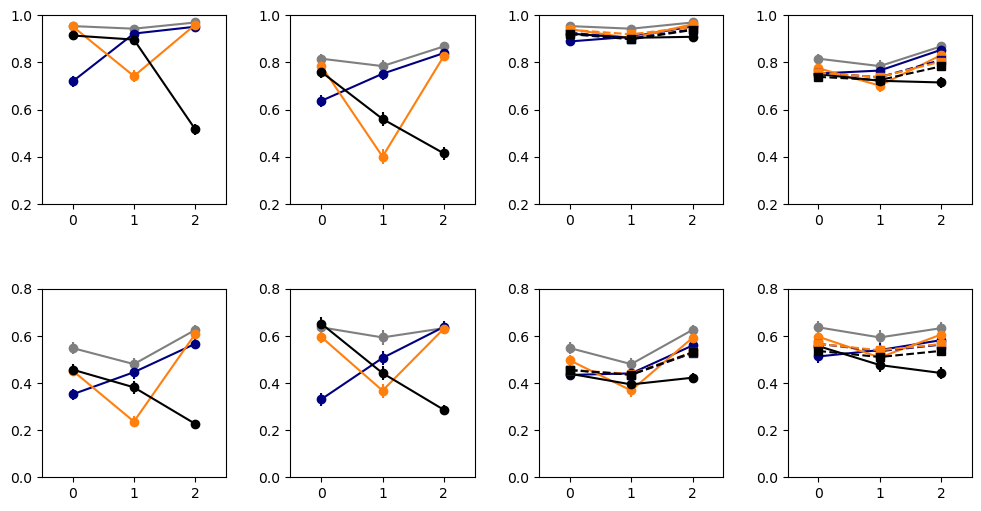

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.45)

state_colors = ['navy', 'tab:orange', 'black']
xticks = (0, 1, 2)
xticklabels = ('A', 'B', 'C')

# subject K, OFC, lesion
ax[0,0].errorbar(xticks, k_ofc_zero_mean[0,:], k_ofc_zero_ci[0,:], color = 'tab:gray', capsize = 0, marker = 'o')
ax[0,0].errorbar(xticks, k_ofc_zero_mean[1,:], k_ofc_zero_ci[1,:], color = state_colors[0], capsize = 0, marker = 'o')
ax[0,0].errorbar(xticks, k_ofc_zero_mean[2,:], k_ofc_zero_ci[2,:], color = state_colors[1], capsize = 0, marker = 'o')
ax[0,0].errorbar(xticks, k_ofc_zero_mean[3,:], k_ofc_zero_ci[3,:], color = state_colors[2], capsize = 0, marker = 'o')
ax[0,0].set_ylim(.2, 1)
ax[0,0].set_xlim(-.5, 2.5)

# subject D, OFC, lesion
ax[0,1].errorbar(xticks, d_ofc_zero_mean[0,:], d_ofc_zero_ci[0,:], color = 'tab:gray', capsize = 0, marker = 'o')
ax[0,1].errorbar(xticks, d_ofc_zero_mean[1,:], d_ofc_zero_ci[1,:], color = state_colors[0], capsize = 0, marker = 'o')
ax[0,1].errorbar(xticks, d_ofc_zero_mean[2,:], d_ofc_zero_ci[2,:], color = state_colors[1], capsize = 0, marker = 'o')
ax[0,1].errorbar(xticks, d_ofc_zero_mean[3,:], d_ofc_zero_ci[3,:], color = state_colors[2], capsize = 0, marker = 'o')
ax[0,1].set_ylim(.2, 1)
ax[0,1].set_xlim(-.5, 2.5)

# subject K, CdN, lesion
ax[1,0].errorbar(xticks, k_cdn_zero_mean[0,:], k_cdn_zero_ci[0,:], color = 'tab:gray', capsize = 0, marker = 'o')
ax[1,0].errorbar(xticks, k_cdn_zero_mean[1,:], k_cdn_zero_ci[1,:], color = state_colors[0], capsize = 0, marker = 'o')
ax[1,0].errorbar(xticks, k_cdn_zero_mean[2,:], k_cdn_zero_ci[2,:], color = state_colors[1], capsize = 0, marker = 'o')
ax[1,0].errorbar(xticks, k_cdn_zero_mean[3,:], k_cdn_zero_ci[3,:], color = state_colors[2], capsize = 0, marker = 'o')
ax[1,0].set_ylim(0, .8)
ax[1,0].set_xlim(-.5, 2.5)

# subject D, CdN, lesion
ax[1,1].errorbar(xticks, d_cdn_zero_mean[0,:], d_cdn_zero_ci[0,:], color = 'tab:gray', capsize = 0, marker = 'o')
ax[1,1].errorbar(xticks, d_cdn_zero_mean[1,:], d_cdn_zero_ci[1,:], color = state_colors[0], capsize = 0, marker = 'o')
ax[1,1].errorbar(xticks, d_cdn_zero_mean[2,:], d_cdn_zero_ci[2,:], color = state_colors[1], capsize = 0, marker = 'o')
ax[1,1].errorbar(xticks, d_cdn_zero_mean[3,:], d_cdn_zero_ci[3,:], color = state_colors[2], capsize = 0, marker = 'o')
ax[1,1].set_ylim(0, .8)
ax[1,1].set_xlim(-.5, 2.5)

# subject K, OFC, dropout
ax[0,2].errorbar(xticks, k_ofc_zero_mean[0,:], k_ofc_zero_ci[0,:], color = 'tab:gray', capsize = 0, marker = 'o')
ax[0,2].errorbar(xticks, k_ofc_remove_mean[0,:], k_ofc_remove_ci[0,:], color=state_colors[0], capsize=0, marker='o', linestyle='-')
ax[0,2].errorbar(xticks, k_ofc_remove_mean[1,:], k_ofc_remove_ci[1,:], color=state_colors[1], capsize=0, marker='o', linestyle='-')
ax[0,2].errorbar(xticks, k_ofc_remove_mean[2,:], k_ofc_remove_ci[2,:], color=state_colors[2], capsize=0, marker='o', linestyle='-')
ax[0,2].errorbar(xticks, k_ofc_rand_mean[0,:], k_ofc_rand_ci[0,:], color=state_colors[0], capsize=0, marker='s', linestyle='--')
ax[0,2].errorbar(xticks, k_ofc_rand_mean[1,:], k_ofc_rand_ci[1,:], color=state_colors[1], capsize=0, marker='s', linestyle='--')
ax[0,2].errorbar(xticks, k_ofc_rand_mean[2,:], k_ofc_rand_ci[2,:], color=state_colors[2], capsize=0, marker='s', linestyle='--')
ax[0,2].set_ylim(.2, 1)
ax[0,2].set_xlim(-.5, 2.5)

# subject D, OFC, dropout
ax[0,3].errorbar(xticks, d_ofc_zero_mean[0,:], d_ofc_zero_ci[0,:], color = 'tab:gray', capsize = 0, marker = 'o')
ax[0,3].errorbar(xticks, d_ofc_remove_mean[0,:], d_ofc_remove_ci[0,:], color=state_colors[0], capsize=0, marker='o', linestyle='-')
ax[0,3].errorbar(xticks, d_ofc_remove_mean[1,:], d_ofc_remove_ci[1,:], color=state_colors[1], capsize=0, marker='o', linestyle='-')
ax[0,3].errorbar(xticks, d_ofc_remove_mean[2,:], d_ofc_remove_ci[2,:], color=state_colors[2], capsize=0, marker='o', linestyle='-')
ax[0,3].errorbar(xticks, d_ofc_rand_mean[0,:], d_ofc_rand_ci[0,:], color=state_colors[0], capsize=0, marker='s', linestyle='--')
ax[0,3].errorbar(xticks, d_ofc_rand_mean[1,:], d_ofc_rand_ci[1,:], color=state_colors[1], capsize=0, marker='s', linestyle='--')
ax[0,3].errorbar(xticks, d_ofc_rand_mean[2,:], d_ofc_rand_ci[2,:], color=state_colors[2], capsize=0, marker='s', linestyle='--')
ax[0,3].set_ylim(.2, 1)
ax[0,3].set_xlim(-.5, 2.5)

# subject K, CdN, dropout
ax[1,2].errorbar(xticks, k_cdn_zero_mean[0,:], k_cdn_zero_ci[0,:], color = 'tab:gray', capsize = 0, marker = 'o')
ax[1,2].errorbar(xticks, k_cdn_remove_mean[0,:], k_cdn_remove_ci[0,:], color=state_colors[0], capsize=0, marker='o', linestyle='-')
ax[1,2].errorbar(xticks, k_cdn_remove_mean[1,:], k_cdn_remove_ci[1,:], color=state_colors[1], capsize=0, marker='o', linestyle='-')
ax[1,2].errorbar(xticks, k_cdn_remove_mean[2,:], k_cdn_remove_ci[2,:], color=state_colors[2], capsize=0, marker='o', linestyle='-')
ax[1,2].errorbar(xticks, k_cdn_rand_mean[0,:], k_cdn_rand_ci[0,:], color=state_colors[0], capsize=0, marker='s', linestyle='--')
ax[1,2].errorbar(xticks, k_cdn_rand_mean[1,:], k_cdn_rand_ci[1,:], color=state_colors[1], capsize=0, marker='s', linestyle='--')
ax[1,2].errorbar(xticks, k_cdn_rand_mean[2,:], k_cdn_rand_ci[2,:], color=state_colors[2], capsize=0, marker='s', linestyle='--')
ax[1,2].set_ylim(0, .8)
ax[1,2].set_xlim(-.5, 2.5)

# subject D, CdN, dropout
ax[1,3].errorbar(xticks, d_cdn_zero_mean[0,:], d_cdn_zero_ci[0,:], color = 'tab:gray', capsize = 0, marker = 'o')
ax[1,3].errorbar(xticks, d_cdn_remove_mean[0,:], d_cdn_remove_ci[0,:], color=state_colors[0], capsize=0, marker='o', linestyle='-')
ax[1,3].errorbar(xticks, d_cdn_remove_mean[1,:], d_cdn_remove_ci[1,:], color=state_colors[1], capsize=0, marker='o', linestyle='-')
ax[1,3].errorbar(xticks, d_cdn_remove_mean[2,:], d_cdn_remove_ci[2,:], color=state_colors[2], capsize=0, marker='o', linestyle='-')
ax[1,3].errorbar(xticks, d_cdn_rand_mean[0,:], d_cdn_rand_ci[0,:], color=state_colors[0], capsize=0, marker='s', linestyle='--')
ax[1,3].errorbar(xticks, d_cdn_rand_mean[1,:], d_cdn_rand_ci[1,:], color=state_colors[1], capsize=0, marker='s', linestyle='--')
ax[1,3].errorbar(xticks, d_cdn_rand_mean[2,:], d_cdn_rand_ci[2,:], color=state_colors[2], capsize=0, marker='s', linestyle='--')
ax[1,3].set_ylim(0, .8)
ax[1,3].set_xlim(-.5, 2.5)

#fig.savefig('decoder_lesioning_fig.svg')


In [60]:
# Create boolean masks to separate trials by subject, intersected with
# the behavioral filter (single saccade, picked best option)
k_trials_mask = bhv['fname'].str.contains('k', case=False) & trials2use
d_trials_mask = bhv['fname'].str.contains('d', case=False) & trials2use

# For each subject × region combination:
#   1. build_anova_df computes the trialwise accuracy drop when each ensemble
#      (A, B, C) is zeroed out, relative to the full decoder, and returns a
#      long-format DataFrame with factors 'lesioned_ensemble' and 'state'
#   2. pg.anova runs a two-way between-subjects ANOVA to test whether the
#      accuracy cost depends on which ensemble was removed (main effect of
#      lesioned_ensemble), which task state the trial was in (main effect of
#      state), and critically whether the cost of removing a given ensemble
#      is larger when the decoder is tested on that ensemble's preferred state
#      (lesioned_ensemble × state interaction)

# subject K, OFC
df_k_ofc = build_anova_df(ofc_t_acc, k_trials_mask, bhv['state'])
aov_k_ofc = pg.anova(data=df_k_ofc, dv='acc_drop', between=['lesioned_ensemble', 'state'])
print('=== Subject K, OFC ===')
print(aov_k_ofc, '\n')

# subject D, OFC
df_d_ofc = build_anova_df(ofc_t_acc, d_trials_mask, bhv['state'])
aov_d_ofc = pg.anova(data=df_d_ofc, dv='acc_drop', between=['lesioned_ensemble', 'state'])
print('=== Subject D, OFC ===')
print(aov_d_ofc, '\n')

# subject K, CdN
df_k_cdn = build_anova_df(cdn_t_acc, k_trials_mask, bhv['state'])
aov_k_cdn = pg.anova(data=df_k_cdn, dv='acc_drop', between=['lesioned_ensemble', 'state'])
print('=== Subject K, CdN ===')
print(aov_k_cdn, '\n')

# subject D, CdN
df_d_cdn = build_anova_df(cdn_t_acc, d_trials_mask, bhv['state'])
aov_d_cdn = pg.anova(data=df_d_cdn, dv='acc_drop', between=['lesioned_ensemble', 'state'])
print('=== Subject D, CdN ===')
print(aov_d_cdn, '\n')

=== Subject K, OFC ===
                      Source          SS      DF         MS           F  \
0          lesioned_ensemble   11.180445     2.0   5.590223   80.318509   
1                      state    0.010635     1.0   0.010635    0.152797   
2  lesioned_ensemble * state   44.920130     2.0  22.460065  322.698941   
3                   Residual  445.792344  6405.0   0.069601         NaN   

           p-unc       np2  
0   3.534709e-35  0.024466  
1   6.958893e-01  0.000024  
2  2.974319e-134  0.091541  
3            NaN       NaN   

=== Subject D, OFC ===
                      Source          SS      DF         MS           F  \
0          lesioned_ensemble    5.489540     2.0   2.744770   23.526006   
1                      state   20.308558     1.0  20.308558  174.068969   
2  lesioned_ensemble * state   55.361559     2.0  27.680780  237.257853   
3                   Residual  610.765373  5235.0   0.116670         NaN   

          p-unc       np2  
0  6.736402e-11  0.008908  